# Hospital Patient Readmission Prediction
Predict whether a diabetic patient will be **readmitted to hospital within 30 days** using the UCI *Diabetes 130-US Hospitals (1999–2008)* dataset.

**Pipeline:** data cleaning → deduplication → SQL analysis → EDA → Random Forest feature selection → Decision Tree classifier (optimised for recall).

Dataset: https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008 (place `diabetic_data.csv` in `data/`).

In [1]:
import pandas as pd, numpy as np, sqlite3
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, recall_score, precision_score, accuracy_score, f1_score, fbeta_score, confusion_matrix, ConfusionMatrixDisplay
import os; os.makedirs('figures', exist_ok=True)
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

## 1. Load data

In [2]:
df = pd.read_csv('data/diabetic_data.csv', na_values='?', low_memory=False)
print('Raw shape:', df.shape)
print('Unique patients:', df.patient_nbr.nunique())
df.head()

Raw shape: (101766, 50)
Unique patients: 71518


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## 2. Data cleaning
- Drop columns with very high missing values (`weight`, `payer_code`, `max_glu_serum`, `A1Cresult`, `medical_specialty`)
- Remove encounters where the patient died or went to hospice (they cannot be readmitted)
- Remove invalid gender rows and rows missing race / primary diagnosis

In [3]:
missing = df.isna().mean().sort_values(ascending=False)
print((missing[missing > 0] * 100).round(1))
df = df.drop(columns=['weight', 'payer_code', 'medical_specialty', 'max_glu_serum', 'A1Cresult'], errors='ignore')
expired_or_hospice = [11, 13, 14, 19, 20, 21]
df = df[~df.discharge_disposition_id.isin(expired_or_hospice)]
df = df[df.gender != 'Unknown/Invalid']
df = df.dropna(subset=['race', 'diag_1'])
print('After cleaning:', df.shape)

weight               96.9
max_glu_serum        94.7
A1Cresult            83.3
medical_specialty    49.1
payer_code           39.6
race                  2.2
diag_3                1.4
diag_2                0.4
diag_1                0.0
dtype: float64
After cleaning: (97090, 45)


## 3. Deduplication — keep one (first) encounter per patient
Multiple encounters of the same patient are not independent, so we keep only each patient's first encounter.

In [4]:
records_before = len(df)
df = df.sort_values('encounter_id').drop_duplicates(subset='patient_nbr', keep='first')
print(f'Records after cleaning: {records_before:,}  ->  unique patients: {len(df):,}')
df['target'] = (df.readmitted == '<30').astype(int)
df.target.value_counts(normalize=True).round(3)

Records after cleaning: 97,090  ->  unique patients: 68,158


target
0    0.91
1    0.09
Name: proportion, dtype: float64

## 4. SQL analysis (SQLite)

In [5]:
con = sqlite3.connect(':memory:')
df.to_sql('patients', con, index=False)
q1 = '''
SELECT age, COUNT(*) AS patients,
       ROUND(100.0 * SUM(target) / COUNT(*), 2) AS readmit_30d_pct
FROM patients GROUP BY age ORDER BY age;'''
display(pd.read_sql(q1, con))
q2 = '''
SELECT diabetesMed AS on_diabetes_medication, COUNT(*) AS patients,
       ROUND(100.0 * SUM(target) / COUNT(*), 2) AS readmit_30d_pct
FROM patients GROUP BY diabetesMed;'''
display(pd.read_sql(q2, con))
q3 = '''
SELECT number_inpatient, COUNT(*) AS patients,
       ROUND(100.0 * SUM(target) / COUNT(*), 2) AS readmit_30d_pct
FROM patients GROUP BY number_inpatient HAVING COUNT(*) > 100 ORDER BY number_inpatient;'''
display(pd.read_sql(q3, con))

,age,patients,readmit_30d_pct
0,[0-10),152,1.97
1,[10-20),526,4.94
2,[20-30),1085,7.56
3,[30-40),2622,7.09
4,[40-50),6637,7.38
5,[50-60),12039,7.16
6,[60-70),15271,9.10
7,[70-80),17299,10.33
8,[80-90),10822,10.79
9,[90-100),1705,9.56


,on_diabetes_medication,patients,readmit_30d_pct
0,No,16347,7.61
1,Yes,51811,9.48


,number_inpatient,patients,readmit_30d_pct
0,0,60039,8.17
1,1,5740,12.94
2,2,1492,18.43
3,3,458,23.58
4,4,224,23.66
5,5,103,28.16


## 5. Exploratory Data Analysis

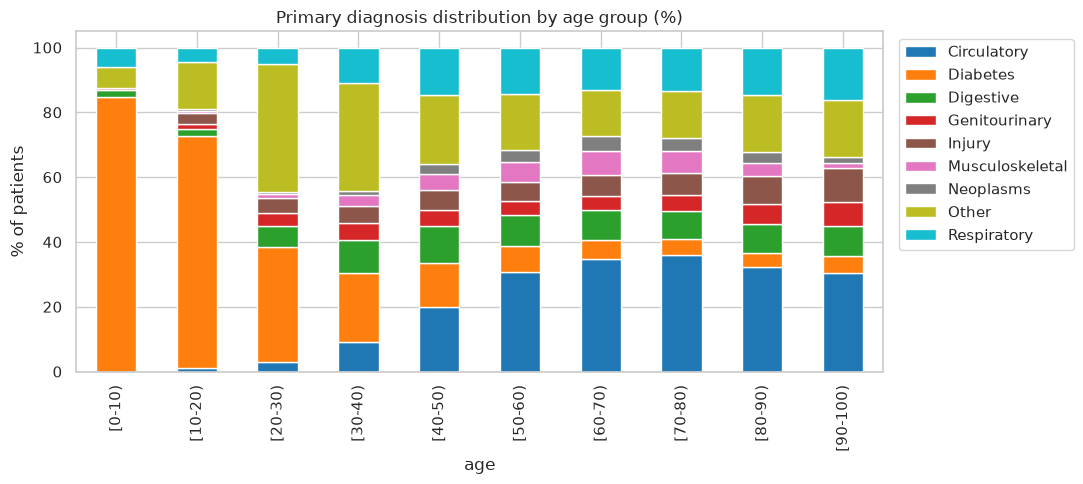

In [6]:
def diag_group(code):
    if pd.isna(code): return 'Other'
    c = str(code)
    if c.startswith(('V', 'E')): return 'Other'
    v = float(c)
    if 390 <= v <= 459 or v == 785: return 'Circulatory'
    if 460 <= v <= 519 or v == 786: return 'Respiratory'
    if 520 <= v <= 579 or v == 787: return 'Digestive'
    if int(v) == 250: return 'Diabetes'
    if 800 <= v <= 999: return 'Injury'
    if 710 <= v <= 739: return 'Musculoskeletal'
    if 580 <= v <= 629 or v == 788: return 'Genitourinary'
    if 140 <= v <= 239: return 'Neoplasms'
    return 'Other'
for c in ['diag_1', 'diag_2', 'diag_3']:
    df[c + '_grp'] = df[c].apply(diag_group)

ct = pd.crosstab(df.age, df.diag_1_grp, normalize='index') * 100
ct.plot(kind='bar', stacked=True, figsize=(11, 5), colormap='tab10')
plt.title('Primary diagnosis distribution by age group (%)'); plt.ylabel('% of patients'); plt.legend(bbox_to_anchor=(1.01, 1))
plt.tight_layout(); plt.savefig('figures/diag_by_age.png', dpi=120); plt.show()

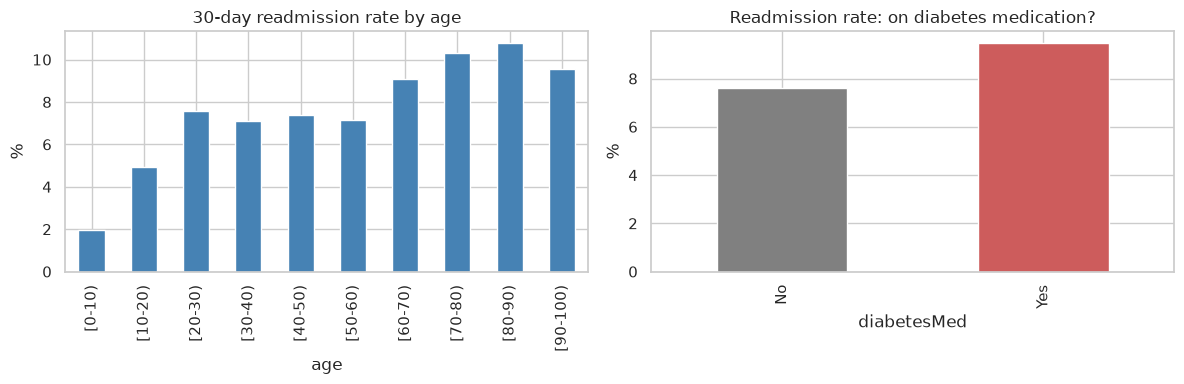

Readmission % by diabetes as primary diagnosis:
diabetes_primary
False    9.03
True     9.09
Name: target, dtype: float64


In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
(df.groupby('age').target.mean() * 100).plot(kind='bar', ax=ax[0], color='steelblue')
ax[0].set_title('30-day readmission rate by age'); ax[0].set_ylabel('%')
(df.groupby('diabetesMed').target.mean() * 100).plot(kind='bar', ax=ax[1], color=['grey', 'indianred'])
ax[1].set_title('Readmission rate: on diabetes medication?'); ax[1].set_ylabel('%')
plt.tight_layout(); plt.savefig('figures/readmission_rates.png', dpi=120); plt.show()
diab = df.assign(diabetes_primary=df.diag_1_grp.eq('Diabetes')).groupby('diabetes_primary').target.mean() * 100
print('Readmission % by diabetes as primary diagnosis:'); print(diab.round(2))

## 6. Feature engineering

In [8]:
drop_cols = ['encounter_id', 'patient_nbr', 'readmitted', 'target', 'diag_1', 'diag_2', 'diag_3']
X = df.drop(columns=drop_cols)
for c in ['admission_type_id', 'discharge_disposition_id', 'admission_source_id']:
    X[c] = X[c].astype(str)
X['age'] = X['age'].str.extract(r'\[(\d+)').astype(int)  # '[70-80)' -> 70
X['total_visits'] = X.number_outpatient + X.number_emergency + X.number_inpatient
cat_cols = X.select_dtypes(['object', 'string']).columns
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
X = X.loc[:, X.nunique() > 1]          # remove constant columns
y = df.target
print('Number of input variables after encoding:', X.shape[1])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

Number of input variables after encoding: 128


## 7. Feature selection with Random Forest importance

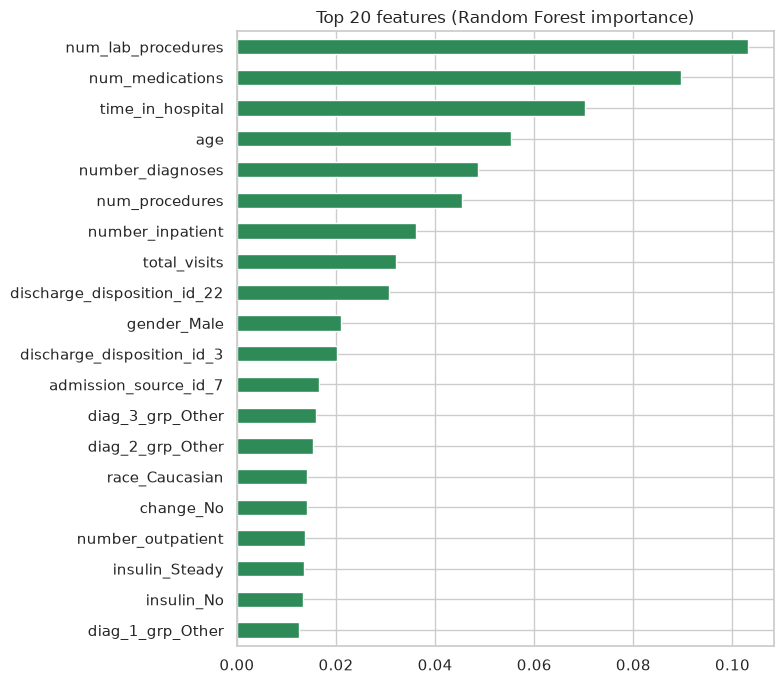

Reduced 128 variables -> 20


In [9]:
rf = RandomForestClassifier(n_estimators=300, class_weight='balanced', min_samples_leaf=5, n_jobs=-1, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
TOP_K = 20
top_features = imp.head(TOP_K).index.tolist()
imp.head(TOP_K).iloc[::-1].plot(kind='barh', figsize=(8, 7), color='seagreen')
plt.title(f'Top {TOP_K} features (Random Forest importance)'); plt.tight_layout(); plt.savefig('figures/feature_importance.png', dpi=120); plt.show()
print(f'Reduced {X.shape[1]} variables -> {TOP_K}')

## 8. Decision Tree classifier (optimised for recall)
`class_weight='balanced'` makes the model care more about the minority (readmitted) class, trading precision for sensitivity — missing an at-risk patient is costlier than a false alarm.

,max_depth,recall,precision,f1,f2,accuracy
0,3,0.391,0.143,0.210,0.290,0.734
1,4,0.550,0.123,0.201,0.324,0.604
2,5,0.526,0.126,0.203,0.321,0.626
3,6,0.470,0.132,0.206,0.310,0.672
4,8,0.438,0.130,0.200,0.297,0.684
5,10,0.471,0.121,0.193,0.298,0.643


Best max_depth: 4
                 precision    recall  f1-score   support

 Not readmitted       0.93      0.61      0.74     12401
Readmitted <30d       0.12      0.55      0.20      1231

       accuracy                           0.60     13632
      macro avg       0.53      0.58      0.47     13632
   weighted avg       0.86      0.60      0.69     13632



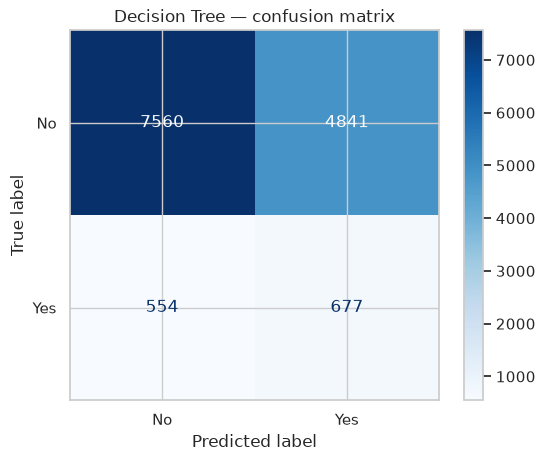

In [10]:
results = []
for depth in [3, 4, 5, 6, 8, 10]:
    dt = DecisionTreeClassifier(max_depth=depth, class_weight='balanced', min_samples_leaf=50, random_state=RANDOM_STATE)
    dt.fit(X_train[top_features], y_train)
    p = dt.predict(X_test[top_features])
    results.append(dict(max_depth=depth, recall=recall_score(y_test, p), precision=precision_score(y_test, p), f1=f1_score(y_test, p), f2=fbeta_score(y_test, p, beta=2), accuracy=accuracy_score(y_test, p)))
res = pd.DataFrame(results).round(3); display(res)
# F2 score weights recall twice as much as precision
best_depth = int(res.sort_values('f2', ascending=False).iloc[0].max_depth)
dt = DecisionTreeClassifier(max_depth=best_depth, class_weight='balanced', min_samples_leaf=50, random_state=RANDOM_STATE)
dt.fit(X_train[top_features], y_train)
pred = dt.predict(X_test[top_features])
print('Best max_depth:', best_depth)
print(classification_report(y_test, pred, target_names=['Not readmitted', 'Readmitted <30d']))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred), display_labels=['No', 'Yes']).plot(cmap='Blues')
plt.title('Decision Tree — confusion matrix'); plt.savefig('figures/confusion_matrix.png', dpi=120); plt.show()

In [11]:
summary = {
 'raw_records': 101766, 'records_after_cleaning': records_before, 'unique_patients': len(df),
 'input_variables': X.shape[1], 'selected_features': TOP_K, 'best_depth': best_depth,
 'recall': round(recall_score(y_test, pred), 3), 'precision': round(precision_score(y_test, pred), 3), 'accuracy': round(accuracy_score(y_test, pred), 3)}
pd.Series(summary).to_json('figures/summary.json'); summary

{'raw_records': 101766,
 'records_after_cleaning': 97090,
 'unique_patients': 68158,
 'input_variables': 128,
 'selected_features': 20,
 'best_depth': 4,
 'recall': 0.55,
 'precision': 0.123,
 'accuracy': 0.604}

## 9. Key findings
See the printed summary above. Use the numbers **you** get when running this notebook in your resume.